In [1]:
import tensorflow as tf
import math, os, random, cv2, numpy, torch
import torch.nn as nn
import pytest
import torch
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

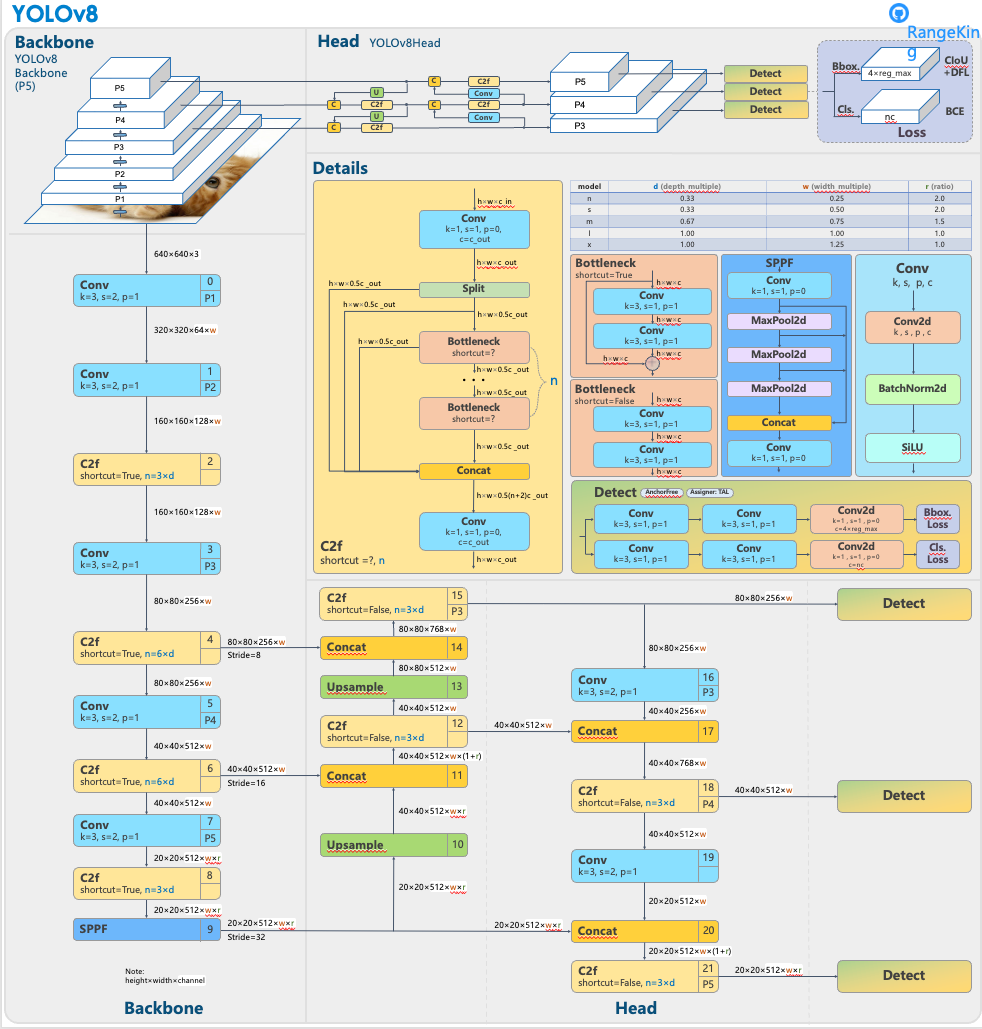

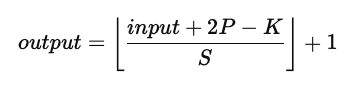
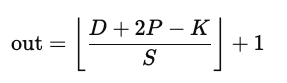
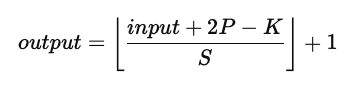

N = batch size
C = channels
H = height
W = width
P - Padding
K - Kernel Size
S - Stride

In [34]:
# P = (K-1)//2 to have input==output

In [18]:
# Official Yolov8 model provided by Ultralytics is pretrained on COCO 2017
# Full name: Microsoft COCO (Common Objects in Context) 2017
# Specifically:
# Train set: ~118,000 images
# Val set: 5,000 images
# 80 object classes

(a) Conv: Conv2d + BatchNorm2d + SiLU

In [2]:
class Conv(nn.Module):
    def __init__(self,in_channels,out_channels,kernel_size=3,stride=1,padding=1,groups=1,activation=True):
        super().__init__()
        self.conv=nn.Conv2d(in_channels,out_channels,kernel_size,stride,padding,bias=False,groups=groups) #Bias = False, because it appears in BatchNorm
        self.bn=nn.BatchNorm2d(out_channels,eps=0.001,momentum=0.03)
        self.act=nn.SiLU(inplace=True) if activation==True else nn.Identity()
    def forward(self,x):
        return self.act(self.bn(self.conv(x)))

(b) C2f (cross-stage partial bottleneck with 2 convolutions): Conv + Bottlenecks + Conv

Combine high-level features with contextual information to improve detection accuracy

In [3]:
# 2.1 Bottleneck: stack of 2 Conv with shortcut connection (True/False)
class Bottleneck(nn.Module):
    def __init__(self, in_channels,out_channels,shortcut=True):
        super().__init__()
        self.conv1 = Conv(in_channels,out_channels,kernel_size=3,stride=1,padding=1)
        self.conv2 = Conv(in_channels,out_channels,kernel_size=3,stride=1,padding=1)
        self.shortcut=shortcut
    def forward(self,x):
        x_in = x # for residual connection
        x = self.conv2(self.conv1(x))
        if self.shortcut:
            x+=x_in
        return x
# 2.2 C2f: Conv + Bottleneck
class C2f(nn.Module):
    def __init__(self,in_channels,out_channels,num_bottlenecks,shortcut=True):
        super().__init__()
        self.mid_channels = out_channels//2
        self.num_bottlenecks = num_bottlenecks
        self.conv1 = Conv(in_channels,out_channels,kernel_size=1,stride=1,padding=0)
        # sequence of bottlenecks layers
        self.m = nn.ModuleList([Bottleneck(self.mid_channels, self.mid_channels, shortcut) for _ in range(num_bottlenecks)])
        self.conv2 = Conv(out_channels*(num_bottlenecks+2)//2,out_channels,kernel_size=1,stride=1,padding=0)
    def forward(self, x):
        x = self.conv1(x)
        # split x along channel dimension
        x1, x2 = x[:,:x.shape[1]//2,:,:], x[:,x.shape[1]//2:,:,:]
        # list of outputs
        outputs = [x1, x2]
        for i in range(self.num_bottlenecks):
            x1=self.m[i](x1) # [bs,0.5c_out,w,h]
            outputs += [x1]
        outputs = torch.cat(outputs,dim=1)
        return self.conv2(outputs) # [bs, 0.5c_out(num_bottlenecks+2),w,h]

In [4]:
# sanity check
c2f=C2f(in_channels=64,out_channels=128,num_bottlenecks=2)
print(f"{sum(p.numel() for p in c2f.parameters())/1e6} million parameters")

dummy_input=torch.rand((1,64,244,244))
dummy_input=c2f(dummy_input)
print("Output shape: ", dummy_input.shape)

0.18944 million parameters
Output shape:  torch.Size([1, 128, 244, 244])


(c) SPPF (spatial pyramid pooling fast): Conv + Maxpool2d + Conv

Process features at various scales and pool them into a fixed-size feature map.

In [5]:
class SPPF(nn.Module):
    def __init__(self,in_channels,out_channels,kernel_size=5):
        super().__init__()
        hidden_channels = in_channels//2
        self.conv1 = Conv(in_channels,hidden_channels,kernel_size=1,stride=1,padding=0)
        # maxpool is applied at 3 different scales
        self.mp = nn.MaxPool2d(kernel_size,stride=1,padding=kernel_size//2, dilation=1, ceil_mode=False)
        self.conv2 = Conv(hidden_channels*4, out_channels, kernel_size=1, stride=1, padding=0)
    def forward(self, x):
        x = self.conv1(x)
        y1 = self.mp(x)
        y2 = self.mp(y1)
        y3 = self.mp(y2)
        y = torch.cat([x,y1,y2,y3],dim=1)
        return self.conv2(y)

In [6]:
sppf = SPPF(in_channels=128, out_channels=512)
# sanity check
sppf=SPPF(in_channels=128,out_channels=512)
print(f"{sum(p.numel() for p in sppf.parameters())/1e6} million parameters")

dummy_input=sppf(dummy_input)
print("Output shape: ", dummy_input.shape)

0.140416 million parameters
Output shape:  torch.Size([1, 512, 244, 244])


The backbone is modified CSPDarknet53 which comprises of blocks Conv, C2f, SPPF

**Conv:** Conv2d + BatchNorm2d + SiLU

**C2f** (cross-stage partial bottleneck with 2 convolutions): Conv + Bottlenecks + Conv

Combine high-level features with contextual information to improve detection accuracy.

**SPPF** (spatial pyramid pooling fast): Conv + Maxpool2d + Conv

Process features at various scales and pool them into a fixed-size feature map.

In [7]:
# return d,w,r based on version
def yolo_params(version):
    if version=='n':
        return 1/3,1/4,2.0
    elif version=='s':
        return 1/3,1/2,2.0
    elif version=='m':
        return 2/3,3/4,1.5
    elif version=='l':
        return 1.0,1.0,1.0
    elif version=='x':
        return 1.0,1.25,1.0

In [11]:
class Backbone(nn.Module):
    def __init__(self,version,in_channels=3,shortcut=True):
        super().__init__()
        d,w,r = yolo_params(version)
        self.conv_p1 = Conv(in_channels,out_channels=int(64*w),kernel_size=3,stride=2,padding=1)
        self.conv_p2 = Conv(in_channels=int(64*w),out_channels=int(128*w),kernel_size=3,stride=2,padding=1)
        self.c2f_2 = C2f(in_channels=int(128*w),out_channels=int(128*w),num_bottlenecks=int(3*d),shortcut=shortcut)
        self.conv_p3 = Conv(in_channels=int(128*w),out_channels=int(256*w),kernel_size=3,stride=2,padding=1)
        self.c2f_4 = C2f(in_channels=int(256*w),out_channels=int(256*w),num_bottlenecks=int(6*d),shortcut=shortcut)
        self.conv_p4 = Conv(in_channels=int(256*w),out_channels=int(512*w),kernel_size=3,stride=2,padding=1)
        self.c2f_6 = C2f(in_channels=int(512*w),out_channels=int(512*w),num_bottlenecks=int(6*d),shortcut=shortcut)
        self.conv_p5 = Conv(in_channels=int(512*w),out_channels=int(512*w*r),kernel_size=3,stride=2,padding=1)
        self.c2f_8 = C2f(in_channels=int(512*w*r),out_channels=int(512*w*r),num_bottlenecks=int(3*d),shortcut=shortcut)
        self.sppf = SPPF(in_channels=int(512*w*r),out_channels=int(512*w*r))
    def forward(self, x):
        x = self.conv_p1(x)
        x = self.conv_p2(x)
        x = self.c2f_2(x)
        x = self.conv_p3(x)
        y1 = self.c2f_4(x)
        x = self.conv_p4(y1)
        y2 = self.c2f_6(x)
        x = self.conv_p5(y2)
        x = self.c2f_8(x)
        y3 = self.sppf(x)
        return y1, y2, y3

print("----Nano model -----")
backbone_n=Backbone(version='n')
print(f"{sum(p.numel() for p in backbone_n.parameters())/1e6} million parameters")

print("----Small model -----")
backbone_s=Backbone(version='s')
print(f"{sum(p.numel() for p in backbone_s.parameters())/1e6} million parameters")




----Nano model -----
1.272656 million parameters
----Small model -----
5.079712 million parameters


In [12]:
# sanity check
x=torch.rand((1,3,640,640))
out1,out2,out3=backbone_n(x)
print(out1.shape)
print(out2.shape)
print(out3.shape)

torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


### 2. Neck

The neck comprises of Upsample + C2f with

**Upsample** = nearest-neighbor interpolation with scale_factor=2. It doesn't have trainable paramaters.

In [13]:
# Upsample = nearest-neighbor interpolation with scale_factor=2 (no trainable parameters)
class Upsample(nn.Module):
    def __init__(self,scale_factor=2,mode='nearest'):
        super().__init__()
        self.scale_factor=scale_factor
        self.mode=mode
    def forward(self,x):
        return nn.functional.interpolate(x,scale_factor=self.scale_factor,mode=self.mode)

In [15]:
class Neck(nn.Module):
    def __init__(self,version):
        super().__init__()
        d,w,r=yolo_params(version)
        self.upsample = Upsample()
        self.c2f_12 = C2f(in_channels=int(512*w*(1+r)), out_channels=int(512*w), num_bottlenecks=int(3*d),shortcut=False)
        self.c2f_15 = C2f(in_channels=int(768*w), out_channels=int(256*w), num_bottlenecks=int(3*d),shortcut=False)
        self.conv_16 = Conv(in_channels=int(256*w), out_channels=int(256*w), kernel_size=3, stride=2, padding=1)
        self.c2f_18 = C2f(in_channels=int(768*w), out_channels=int(512*w), num_bottlenecks=int(3*d),shortcut=False)
        self.conv_19 = Conv(in_channels=int(512*w), out_channels=int(512*w), kernel_size=3, stride=2, padding=1)
        self.c2f_21 = C2f(in_channels=int(512*w*(1+r)), out_channels=int(512*w*r), num_bottlenecks=int(3*d),shortcut=False)
    def forward(self, *args):
        if len(args) != 3:
            raise ValueError("Expected 3 inputs")
        inp_14, inp_11, inp_10 = args
        x = self.upsample(inp_10)
        x = [x, inp_11]
        x = torch.cat(x, dim=1)
        inp_17 = self.c2f_12(x)
        x = self.upsample(inp_17)
        x = [x, inp_14]
        x = torch.cat(x, dim=1)
        y1 = self.c2f_15(x)
        x = self.conv_16(y1)
        x = [x, inp_17]
        x = torch.cat(x, dim=1)
        y2 = self.c2f_18(x)
        x = self.conv_19(y2)
        x = [x, inp_10]
        x = torch.cat(x, dim=1)
        y3 = self.c2f_21(x)
        return y1, y2, y3

# sanity check
neck=Neck(version='n')
print(f"{sum(p.numel() for p in neck.parameters())/1e6} million parameters")

x=torch.rand((1,3,640,640))
out1,out2,out3=Backbone(version='n')(x)
out_1,out_2,out_3=neck(out1,out2,out3)
print(out_1.shape)
print(out_2.shape)
print(out_3.shape)

0.98688 million parameters
torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


d
### 3. Head

Consist of 3 modules: (1) bbox coordinates, (2) classification scores, (3) distribution focal loss (DFL).

**DFL** considers the predicted bbox coordinates as a probability distribution. At inference time, it samples from the distribution to get refined coordinates (x, y, w, h). For example, to predict coordinate x in the normalized range [0,1]:

1. DFL uses 16 bins which are equally spaced in [0, 1], bin length = 1/16.

2. The model outputs 16 numbers which corresponds to probabilities that x falls in these bins, for example, [0, 0, ..., 9/10, 1/10].

3. Prediction for x = mean value = 9/10 * 15/16 + 1/10 * 1 = 0.94375

In [44]:
from ultralytics import YOLO
model = YOLO("../models/yolov8n.pt")

In [ ]:
# dir = '/Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/tmp/runs'
# model = YOLO("../models/yolov8n.pt")
# model.val(imgsz=640,device="mps",project=dir,name='coco_val',save_conf=True,save_txt=True)

Ultralytics 8.4.6 🚀 Python-3.11.14 torch-2.9.1 MPS (Apple M3 Pro)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco.yaml' images not found, missing path '/Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/datasets/coco/val2017.txt'
Unzipping /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/datasets/coco2017labels-segments.zip to /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/datasets/coco...: 100% ━━━━━━━━━━━━ 122232/122232 8.7Kfiles/s 14.1s<0.0s
Unzipping /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/datasets/coco/images/val2017.zip to /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/datasets/coco/ima

In [2]:
from ultralytics.data.converter import convert_coco

# Convert COCO annotations to YOLO format
path_coco = '/Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/datasets/coco/annotations'
save_dir = '/Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco/train'
convert_coco(path_coco, save_dir, use_segments=True, use_keypoints=False, cls91to80=True)

Annotations /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/datasets/coco/annotations/instances_val2017.json: 100% ━━━━━━━━━━━━ 4952/4952 4.5Kit/s 1.1s0.1s
COCO data converted successfully.
Results saved to /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco/train2


In [36]:
dir = '/Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/tmp/runs'
metrics = model.val(data="../datasets/coco/data.yaml",split="val",imgsz=640,device="mps",project=dir,name='coco_val',save_conf=True,save_txt=True)
print(metrics.box.map)      # mAP50-95
print(metrics.box.map50)    # mAP@0.5

Ultralytics 8.4.6 🚀 Python-3.11.14 torch-2.9.1 MPS (Apple M3 Pro)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 636.9±246.1 MB/s, size: 162.8 KB)
val: Scanning /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco/valid/labels... 4952 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 6.0Kit/s 0.8s0.0s
val: New cache created: /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 313/313 1.2s/it 6:25<1.2s
                   all       5000      36335      0.634      0.475      0.521      0.37

In [35]:
# from ultralytics.data.converter import convert_coco
#
# convert_coco(
#     "../datasets/coco/annotations",
#     use_segments=False,
#     use_keypoints=False,
#     cls91to80=True, # Maps 91 COCO classes to the standard 80,
#     save_dir='../datasets/coco/valid/labels'
# )


Annotations /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco/annotations/instances_val2017.json: 100% ━━━━━━━━━━━━ 4952/4952 7.6Kit/s 0.7s0.1s
COCO data converted successfully.
Results saved to /Users/helbuk/Library/Mobile Documents/com~apple~CloudDocs/NTNU/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco/valid/labels2


In [45]:
model_eval = model.model.eval()
model_eval

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [46]:
model.predict(source='../datasets/coco/valid/images/000000000139.jpg', verbose=False)

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [47]:
activations = {}
hooks = []
for i, layer in enumerate(model_eval.model):
        def make_hook(idx):
            def hook(module, inp, out):
                # store raw output (tensor or list/tuple)
                activations[idx] = out
            return hook
        hooks.append(layer.register_forward_hook(make_hook(i)))
_ = model.predict(source='../datasets/coco/valid/images/000000000139.jpg', verbose=False)
for h in hooks:
        h.remove()
rows = []
for i, layer in enumerate(model_eval.model):
    layer_name = f"{i:03d}_{layer.__class__.__name__}"
    out = activations.get(i, None)
    print(out)
    break

tensor([[[[ 1.7038e+01,  1.3481e+00,  1.3481e+00,  ...,  1.3481e+00,  1.3481e+00,  1.3481e+00],
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00],
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00],
          ...,
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00],
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00],
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00]],

         [[-1.4360e-04, -4.9904e-05, -4.9904e-05,  ..., -4.9904e-05, -4.9904e-05, -4.9904e-05],
          [-4.9731e-04, -1.7957e-04, -1.7957e-04,  ..., -1.7957e-04, -1.7957e-04, -1.7957e-04],
          [-4.9731e-04, -1.7957e-04, -1.7957e-04,  ..., -1.7957e-04, -1.7957e-04, -1.7957e-04],
          ...,
          [-4.9731e-04, -1.7957e-04, -1.7957e-04,  ..., -1.7957e-04, -1.7957e-04, -1.7957e-04],
        

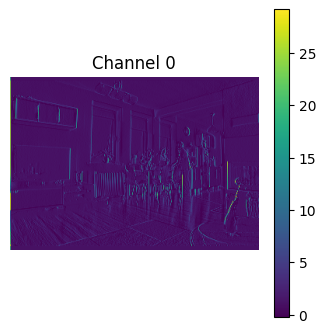

In [48]:
import matplotlib.pyplot as plt
import torch

# assume out is your tensor
# out shape: (1, C, H, W)
x = out[0]              # (C, H, W)
ch = 0                  # choose channel index

plt.figure(figsize=(4, 4))
plt.imshow(x[ch].cpu(), cmap="viridis")
plt.colorbar()
plt.title(f"Channel {ch}")
plt.axis("off")
plt.show()


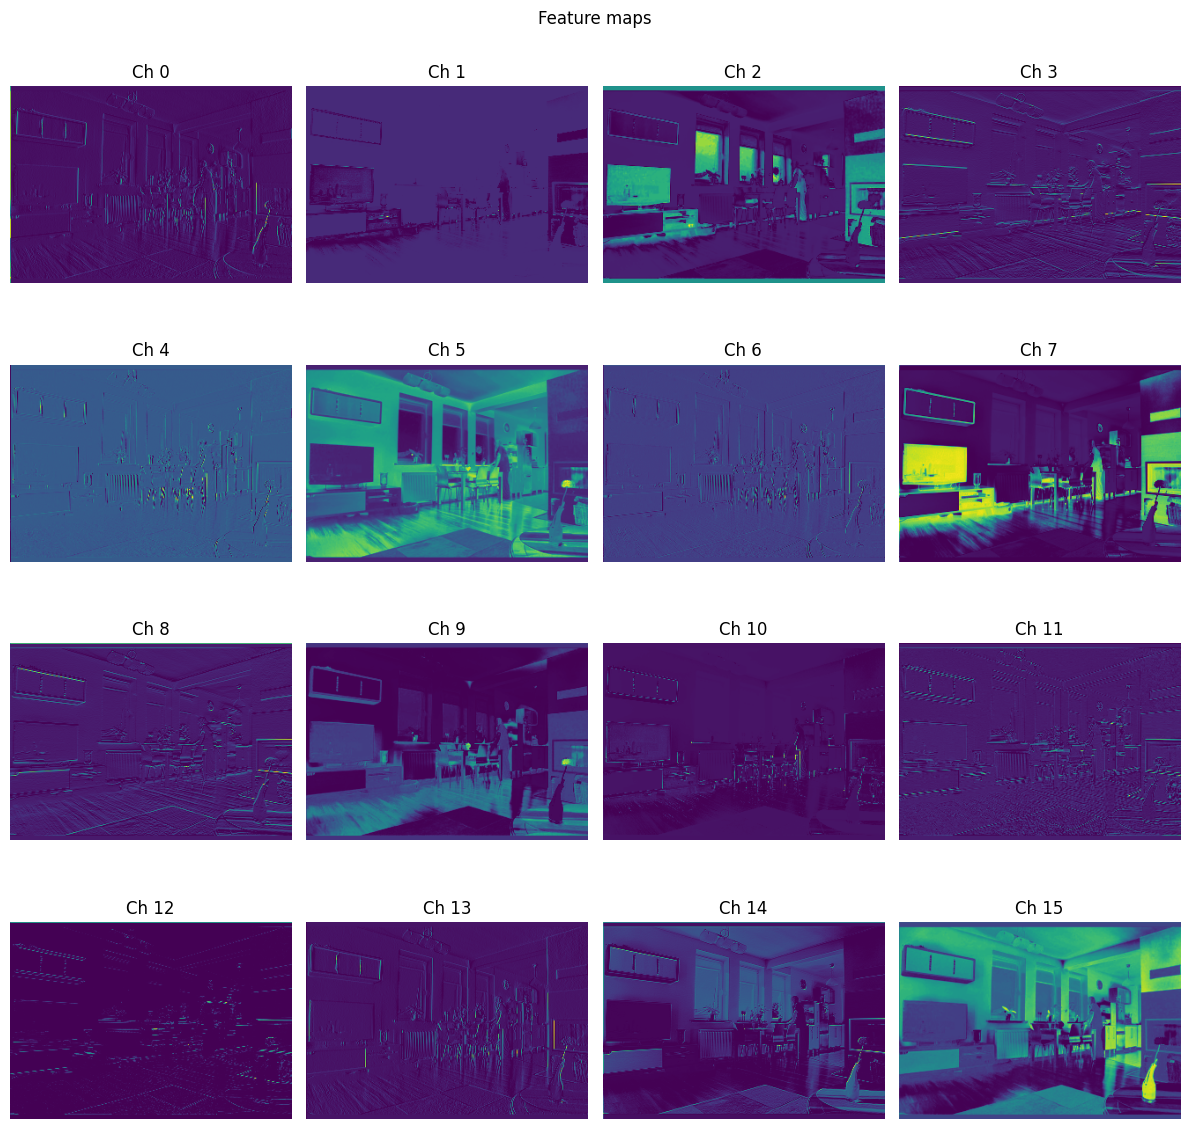

In [49]:
import matplotlib.pyplot as plt
import math

x = out[0]          # (C, H, W)
C = x.shape[0]
n = min(C, 16)      # show first 16 channels

cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 3, rows * 3))
for i in range(n):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x[i].cpu(), cmap="viridis")
    plt.title(f"Ch {i}")
    plt.axis("off")

plt.suptitle("Feature maps")
plt.tight_layout()
plt.show()


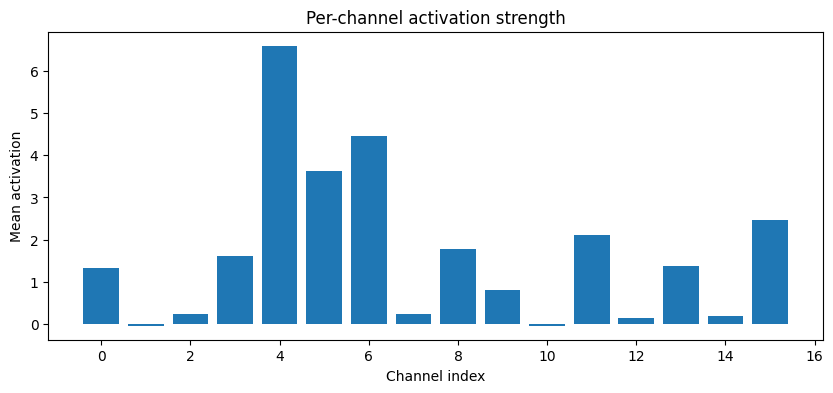

In [50]:
import matplotlib.pyplot as plt

# compute per-channel mean
channel_mean = x.mean(dim=(1, 2)).cpu().numpy()

plt.figure(figsize=(10, 4))
plt.bar(range(len(channel_mean)), channel_mean)
plt.xlabel("Channel index")
plt.ylabel("Mean activation")
plt.title("Per-channel activation strength")
plt.show()


IndexError: index 9 is out of bounds for axis 0 with size 9

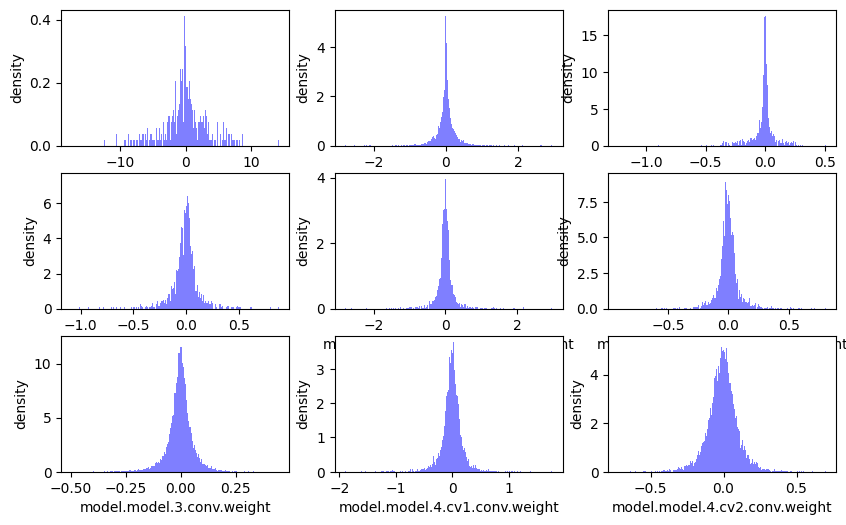

In [51]:
def plot_weight_distribution(model, bins=256, count_nonzero_only=False):
    fig, axes = plt.subplots(3,3, figsize=(10, 6))
    axes = axes.ravel()
    plot_index = 0
    for name, param in model.named_parameters():
        if param.dim() > 1:
            ax = axes[plot_index]
            if count_nonzero_only:
                param_cpu = param.detach().view(-1).cpu()
                param_cpu = param_cpu[param_cpu != 0].view(-1)
                ax.hist(param_cpu, bins=bins, density=True,
                        color = 'blue', alpha = 0.5)
            else:
                ax.hist(param.detach().view(-1).cpu(), bins=bins, density=True,
                        color = 'blue', alpha = 0.5)
            ax.set_xlabel(name)
            ax.set_ylabel('density')
            plot_index += 1
    fig.suptitle('Histogram of Weights')
    fig.tight_layout()
    fig.subplots_adjust(top=0.925)
    plt.show()

plot_weight_distribution(model)

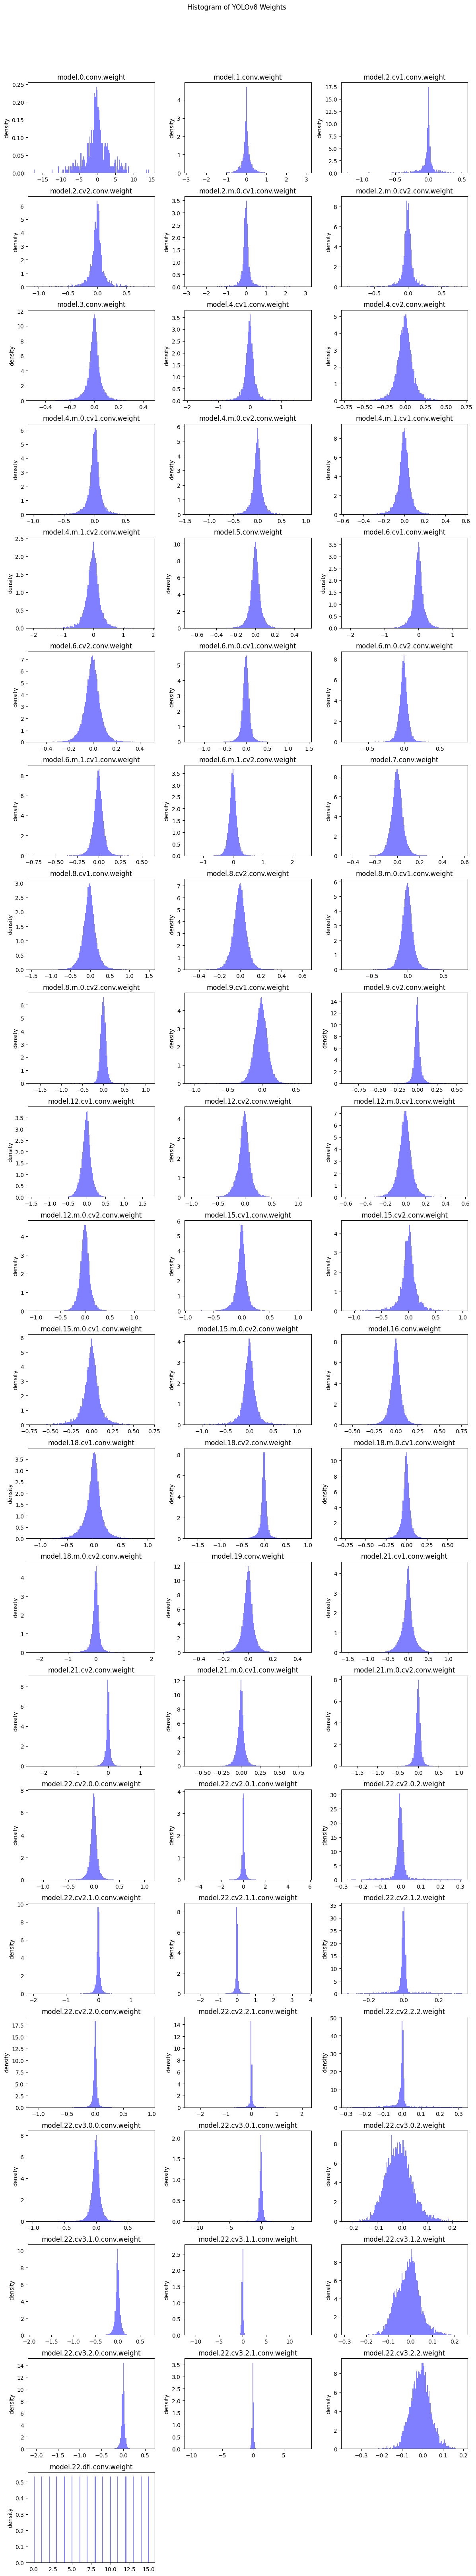

In [52]:
import torch
import matplotlib.pyplot as plt
import math

def plot_weight_distribution(yolo_model, bins=256, count_nonzero_only=False):
    # Access the internal PyTorch model
    net = yolo_model.model

    # Collect only weight tensors (Conv, Linear etc.)
    params = [(name, p) for name, p in net.named_parameters() if p.dim() > 1]

    n = len(params)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
    axes = axes.ravel()

    for i, (name, param) in enumerate(params):
        ax = axes[i]

        param_cpu = param.detach().view(-1).cpu()

        if count_nonzero_only:
            param_cpu = param_cpu[param_cpu != 0]

        ax.hist(param_cpu.numpy(), bins=bins, density=True,
                color='blue', alpha=0.5)

        ax.set_title(name)
        ax.set_ylabel("density")

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Histogram of YOLOv8 Weights")
    fig.tight_layout()
    fig.subplots_adjust(top=0.95)
    plt.show()
plot_weight_distribution(model, bins=128, count_nonzero_only=False)